In [45]:
from sklearn.datasets import make_classification
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score , precision_score , recall_score

In [46]:
X, y = make_classification(
    n_samples=1000,
    n_features=10,
    n_informative=5,
    n_redundant=3,
    random_state=42)

X_train,X_test,y_train,y_test = train_test_split(X,y , test_size=0.2 , random_state = 40)

In [47]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [48]:
knn = KNeighborsClassifier()

In [55]:
model1 = knn.fit(X_train,y_train)

In [56]:
model2 = knn.fit(X_train_scaled,y_train)

In [60]:
y_pred1 = knn.predict(X_test)

In [61]:
print("ACCURACY SCORE :",accuracy_score(y_test,y_pred1))

ACCURACY SCORE : 0.9


In [62]:
y_pred2 = knn.predict(X_test_scaled)

In [63]:
print("ACCURACY SCORE :",accuracy_score(y_test,y_pred2))

ACCURACY SCORE : 0.92


In [64]:
scores = []
for i in range (1,10):
    knn = KNeighborsClassifier(n_neighbors=i)
    knn.fit(X_train,y_train)
    y_pred = knn.predict(X_test)
    scores.append(accuracy_score(y_test,y_pred))

print(scores)

[0.94, 0.9, 0.95, 0.93, 0.94, 0.94, 0.95, 0.95, 0.955]


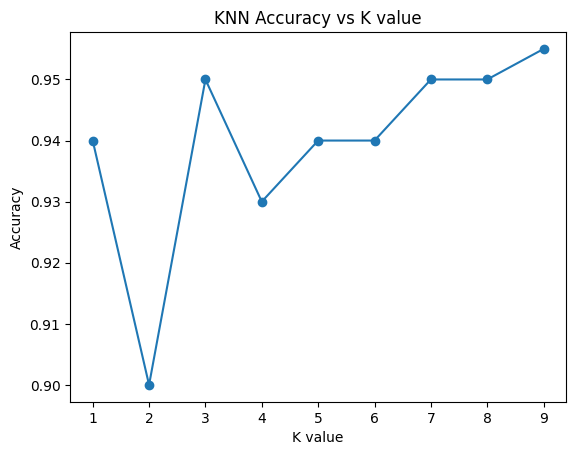

Best K: 9
Best accuracy: 0.955


In [65]:
import matplotlib.pyplot as plt

plt.plot(range(1, 10), scores, marker='o')
plt.xlabel('K value')
plt.ylabel('Accuracy')
plt.title('KNN Accuracy vs K value')
plt.xticks(range(1, 10))
plt.show()

print("Best K:", scores.index(max(scores)) + 1)
print("Best accuracy:", max(scores))

## Key Findings

- KNN accuracy improved from 90% to 92% after feature scaling
- This confirms KNN is sensitive to feature scale — always scale before using KNN
- Best K value = 9 for this dataset
- Too small K (K=1) = overfitting, too large K = underfitting
- KNN stores all training data — no actual training phase (lazy learning)